# Tests with one agent only

In [8]:
# The tests are particularly interesting with Watts-Strogatz networks
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import mesa

# Set a seed
np.random.seed(666)

# Plotting settings

from helpers import plot_all_agent_graphs
# Graphs font
plt.rcParams['font.family'] = 'Georgia'
color_dict = {
    'Anti - environment': 'orange',
    
    'Neutral': 'blue',
    'Pro - environment': 'green'
}

from model_statusgame import statusgame_model
from one_agent_subclass import OneActiveStatusGameModel

In [ ]:
all_agents_game = statusgame_model(N=250, seed=666, lambda_s=1, memory=100,
        create_network="watts_strogatz", p=1/50, gamma=2, k=80, rho=1/3, seed_consumption=True)

one_agent_game = OneActiveStatusGameModel(N=250, one_active_agent_id=1, seed=666, lambda_s=1, memory=100,
        create_network="watts_strogatz", p=0.1, gamma=2, k=80, rho=1/3, seed_consumption=True)


In [10]:
# Run the models
for _ in range(100):
    all_agents_game.step()
    one_agent_game.step()

# Collect dataframes
all_agents_df = all_agents_game.datacollector.get_agent_vars_dataframe().reset_index()
one_agent_df = one_agent_game.datacollector.get_agent_vars_dataframe().reset_index()

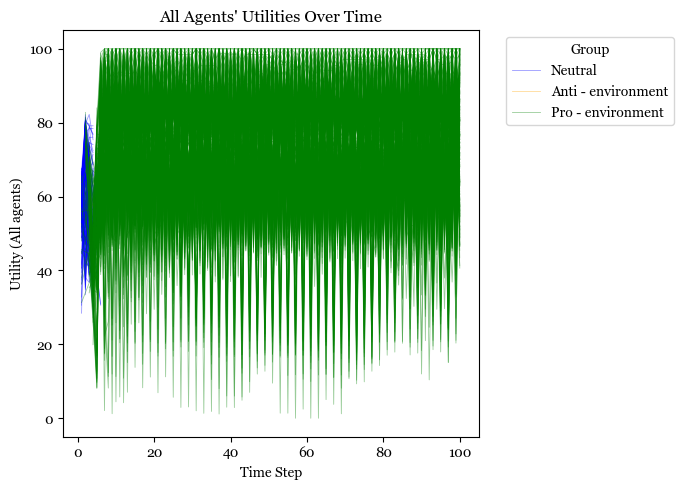

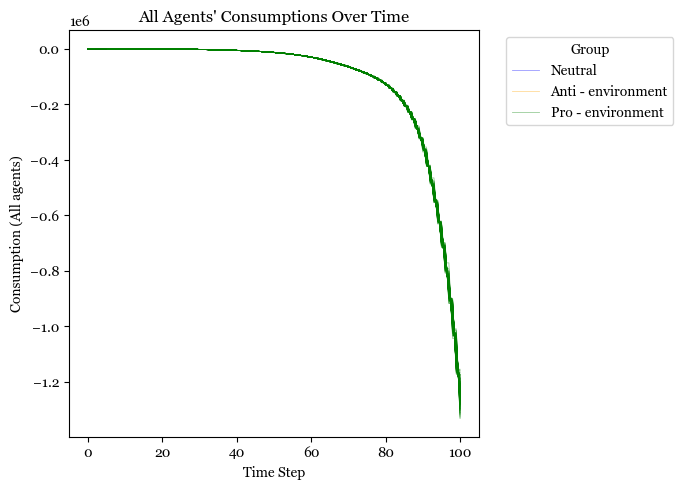

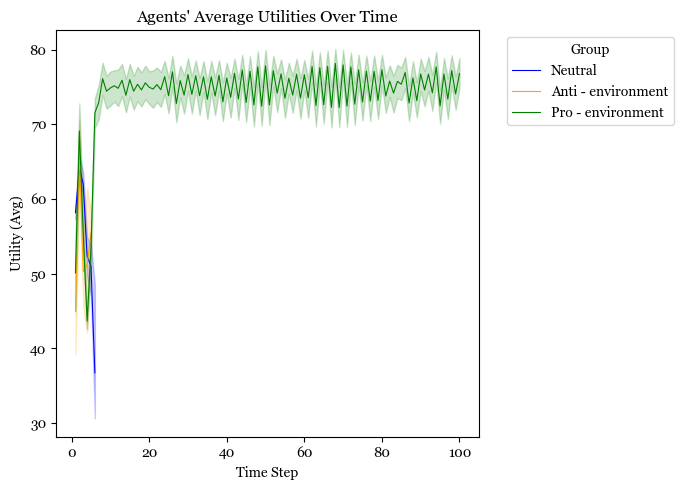

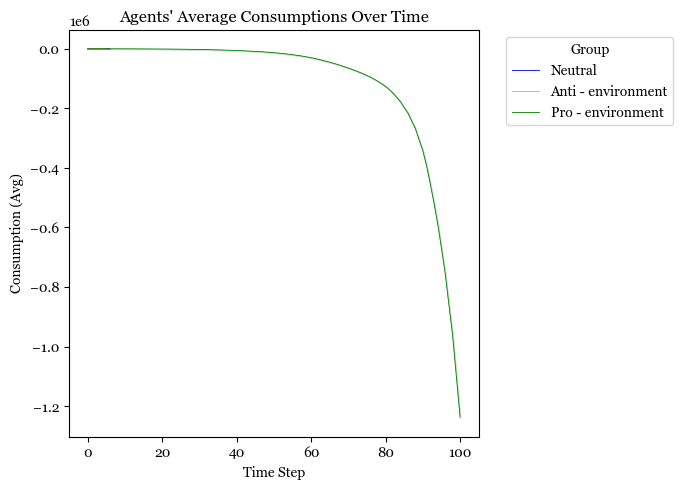

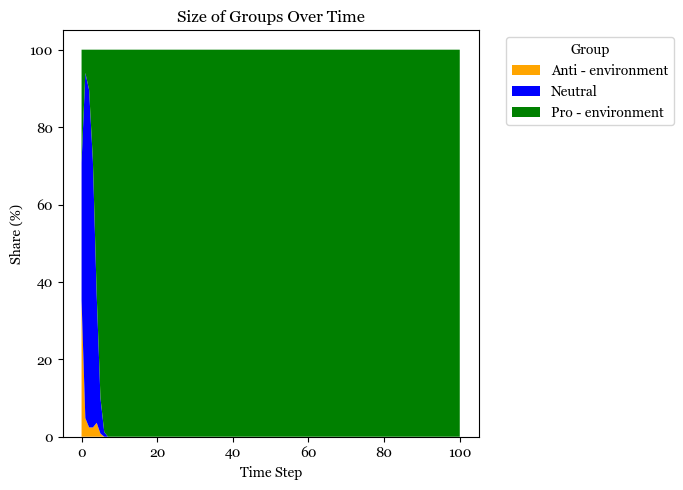

In [11]:
plot_all_agent_graphs(all_agents_df, color_dict, output_folder="plots/all", show_plots=True)

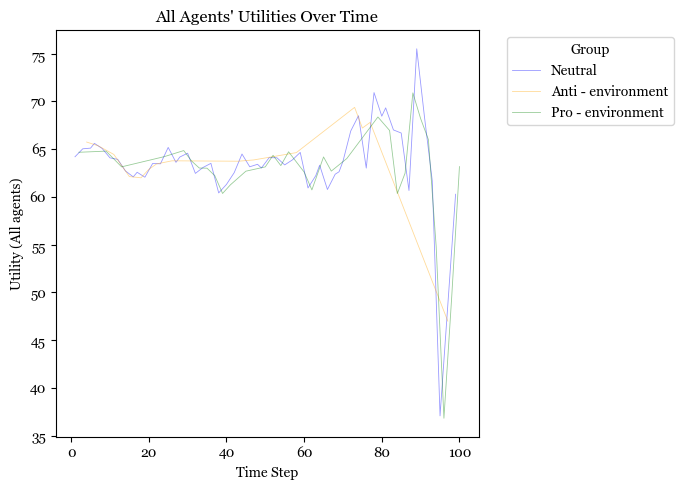

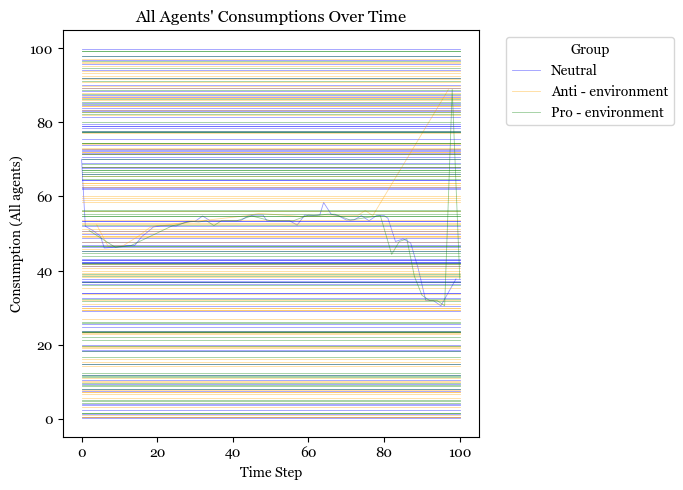

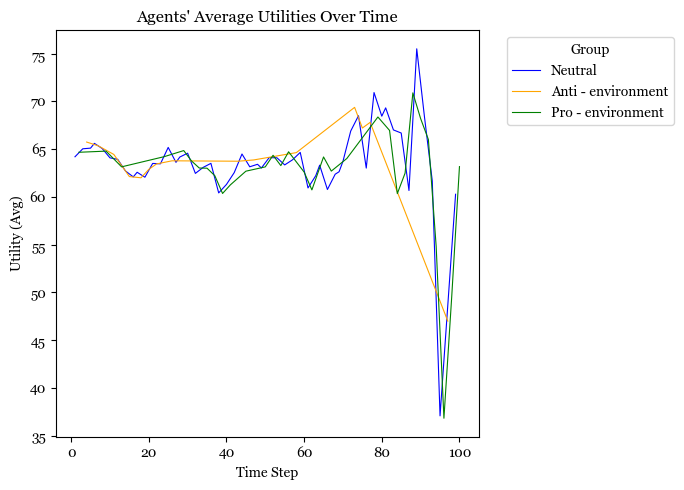

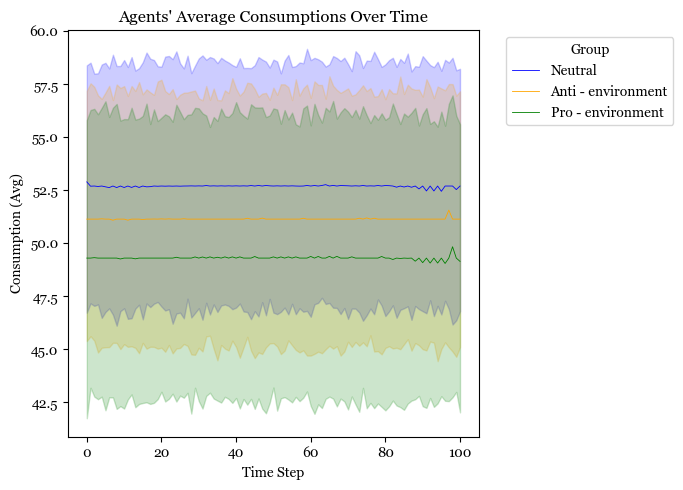

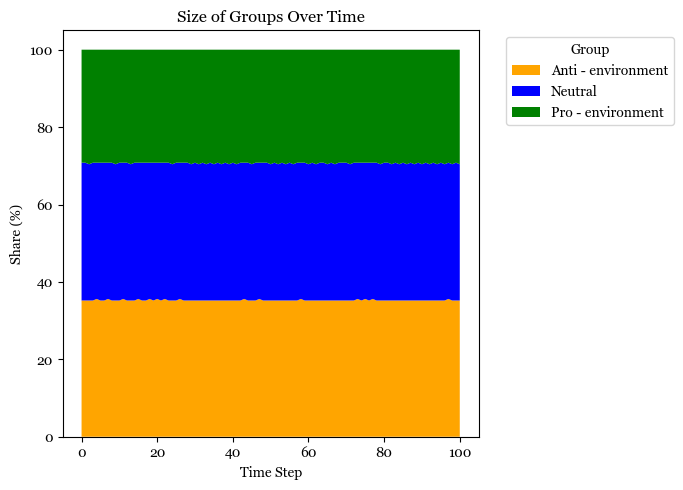

In [12]:
plot_all_agent_graphs(one_agent_df, color_dict, output_folder="plots/one", show_plots=True)

In [13]:
timeline_1 = one_agent_df.loc[one_agent_df["AgentID"] == 1]

In [14]:
timeline_1.loc[:, ["u_anti", "u_neutral", "u_pro"]].describe()

,u_anti,u_neutral,u_pro
count,100.000000,100.000000,100.000000
mean,46.462833,62.889788,49.598675
std,18.341242,5.622729,15.570718
min,0.000000,33.785714,10.000000
25%,29.649015,62.477916,35.714286
50%,55.163690,63.436413,58.765305
75%,63.189176,64.735926,63.413403
max,69.367132,75.494505,70.884354
